<a href="https://colab.research.google.com/github/FlorentGrenier/squirrel-pose-estimation/blob/main/SquirrelKeypoints.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Installation de yt-dlp pour récupérer des vidéos YouTube
!pip install yt-dlp

import cv2
import os
from google.colab.patches import cv2_imshow # Pour afficher des images dans Colab

# Créer un dossier pour stocker nos images extraites
if not os.path.exists('sequence_saut_ecureuil'):
    os.makedirs('sequence_saut_ecureuil', exist_ok=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 45.4 MB/s eta 0:00:00


# Télécharger une vidéo de test

In [ ]:
url_video = "https://www.youtube.com/watch?v=TNFEyC02_io"
!yt-dlp -f mp4 --download-sections "*00:24-02:30" -o "extrait_saut.mp4" "{url_video}"

         Pre-merged mp4 formats are not available from all sites, or may only be available in lower quality.
         To prioritize the best h264 video and aac audio in an mp4 container, use "-t mp4" instead.
         If you know what you are doing and want a pre-merged mp4 format, use "-f b[ext=mp4]" instead to suppress this warning
[youtube] Extracting URL: https://www.youtube.com/watch?v=TNFEyC02_io
[youtube] TNFEyC02_io: Downloading webpage
[youtube] TNFEyC02_io: Downloading android vr player API JSON
[info] TNFEyC02_io: Downloading 1 format(s): 18
[info] TNFEyC02_io: Downloading 1 time ranges: 24.0-150.0
[download] Destination: extrait_saut.mp4
Input #0, mov,mp4,m4a,3gp,3g2,mj2, from 'https://rr1---sn-p5qs7nzk.googlevideo.com/videoplayback?expire=1780811361&ei=AbIkatCPMImAkucPz-a1sAE&ip=34.21.13.163&id=o-AH6dvBQwSPqf27rM2Ta3aVh6GBMGaHWHm1Vg_xiLnSGK&itag=18&source=youtube&requiressl=yes&xpc=EgVo2aDSNQ%3D%3D&met=1780789761%2C&mh=oG&mm=31%2C26&mn=sn-p5qs7nzk%2Csn-ab5l6nkd&ms=au%2Conr

# Extraire les images (Frames)

In [ ]:
video_path = 'extrait_saut.mp4'
cap = cv2.VideoCapture(video_path)

frame_idx = 0
saved_idx = 0
step = 3  # Ajuste cette valeur (ex: 1 pour TOUTES les images, 5 pour moins d'images)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Extraction périodique
    if frame_idx % step == 0:
        # On renomme proprement chaque image extraite
        filename = f"sequence_saut_ecureuil/frame_{saved_idx:04d}.jpg"
        cv2.imwrite(filename, frame)
        saved_idx += 1

    frame_idx += 1

cap.release()
print(f"Extraction réussie ! {saved_idx} images ont été enregistrées dans le dossier 'sequence_saut_ecureuil'.")

Extraction réussie ! 1259 images ont été enregistrées dans le dossier 'sequence_saut_ecureuil'.


# Visualiser une image pour tes futurs Keypoints

Aperçu d'une frame pour tes futurs keypoints :


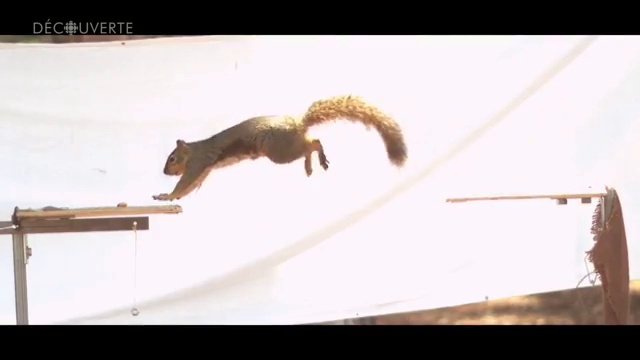

In [ ]:
# Remplacer 'frame_0035.jpg' par une autre si tu veux explorer la séquence
test_img_path = 'sequence_saut_ecureuil/frame_0036.jpg'

if os.path.exists(test_img_path):
    img = cv2.imread(test_img_path)
    # Redimensionnement pour l'affichage Colab
    img_disp = cv2.resize(img, (640, 360))
    print("Aperçu d'une frame pour tes futurs keypoints :")
    cv2_imshow(img_disp)
else:
    print("L'image sélectionnée n'existe pas encore. Vérifie la liste de ton dossier.")

In [ ]:
import shutil

# Compresse le dossier en fichier .zip
shutil.make_archive('images_ecureuil', 'zip', 'sequence_saut_ecureuil')
print("Fichier images_ecureuil.zip créé ! Télécharge-le depuis le panneau de gauche 📁.")

Fichier images_ecureuil.zip créé ! Télécharge-le depuis le panneau de gauche 📁.


In [ ]:
import zipfile
import os

# Remplace 'ton_fichier.zip' par le nom exact de ton fichier s'il est différent
zip_path = 'sous_echantillons_images_ecureuil.zip'
target_dir = '/content/datasets/ecureuil_project'

os.makedirs(target_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(target_dir)

print(f"Jeu de données extrait avec succès dans : {target_dir}")

Jeu de données extrait avec succès dans : /content/datasets/ecureuil_project


CSV RoboFlow -> yolo pose

In [ ]:
import json
import pandas as pd
from pathlib import Path

CSV_FILES = [
    "shard-0_aggregated_results.csv",
    "shard-1_aggregated_results.csv",
]

OUTPUT_LABELS_DIR = Path("predicted_labels")
OUTPUT_LABELS_DIR.mkdir(exist_ok=True)

# Ordre RoboFlow détecté dans ton CSV
KEYPOINT_ORDER = [
    "nose",
    "middle_back",
    "front_right_leg",
    "front_left_leg",
    "back_left_leg",
    "back_right_leg",
    "base_tail",
    "tip_tail",
]

CONF_THRESHOLD_VISIBLE = 0.50


def normalize(value, size):
    return max(0.0, min(1.0, value / size))


def convert_row(row):
    raw = row["squirrel_keypoint_predictions"]

    if pd.isna(raw) or not raw.strip():
        return None

    data = json.loads(raw)

    image_w = data["image"]["width"]
    image_h = data["image"]["height"]
    predictions = data.get("predictions", [])

    if not predictions:
        return None

    pred = predictions[0]

    # Bounding box YOLO normalisée
    x_center = normalize(pred["x"], image_w)
    y_center = normalize(pred["y"], image_h)
    width = normalize(pred["width"], image_w)
    height = normalize(pred["height"], image_h)

    keypoints_by_name = {
        kp["class"]: kp
        for kp in pred.get("keypoints", [])
    }

    values = [
        "0",  # class_id Squirrel
        f"{x_center:.8f}",
        f"{y_center:.8f}",
        f"{width:.8f}",
        f"{height:.8f}",
    ]

    for name in KEYPOINT_ORDER:
        kp = keypoints_by_name.get(name)

        if kp is None:
            values.extend(["0.00000000", "0.00000000", "0"])
            continue

        x = normalize(kp["x"], image_w)
        y = normalize(kp["y"], image_h)
        conf = kp.get("confidence", 1.0)

        visibility = 2 if conf >= CONF_THRESHOLD_VISIBLE else 1

        values.extend([
            f"{x:.8f}",
            f"{y:.8f}",
            str(visibility),
        ])

    return " ".join(values)


def main():
    df = pd.concat(
        [pd.read_csv(path) for path in CSV_FILES],
        ignore_index=True
    )

    generated = 0
    skipped = 0

    for _, row in df.iterrows():
        image_name = row["image"]
        label_content = convert_row(row)

        if label_content is None:
            skipped += 1
            continue

        label_name = Path(image_name).with_suffix(".txt").name
        output_path = OUTPUT_LABELS_DIR / label_name

        output_path.write_text(label_content, encoding="utf-8")
        generated += 1

    print(f"Labels générés : {generated}")
    print(f"Images ignorées sans prédiction : {skipped}")
    print(f"Dossier de sortie : {OUTPUT_LABELS_DIR.resolve()}")


if __name__ == "__main__":
    main()

Labels générés : 622
Images ignorées sans prédiction : 187
Dossier de sortie : /content/predicted_labels


In [ ]:
import shutil
from google.colab import files
import os

folder_to_download = 'predicted_labels'
zip_filename = f'{folder_to_download}.zip'

# Create a zip archive of the folder
shutil.make_archive(folder_to_download, 'zip', folder_to_download)

# Download the zip file
print(f"Le dossier '{folder_to_download}' a été compressé en '{zip_filename}'. Téléchargement en cours...")
files.download(zip_filename)
print("Téléchargement terminé !")

Le dossier 'predicted_labels' a été compressé en 'predicted_labels.zip'. Téléchargement en cours...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Téléchargement terminé !
